In [16]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel, LdaModel
import pyLDAvis
import pyLDAvis.gensim_models
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pickle
import os

os.makedirs('resultModel_LDA', exist_ok=True)
print("Gensim version:", gensim.__version__)

Gensim version: 4.3.1


In [17]:
df = pd.read_csv('ready_data_LDA.csv')
df['tokens'] = df['stemmed'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)
print(f"Jumlah dokumen setelah filter: {len(df)}")
print("Contoh token dokumen pertama:", df['tokens'].iloc[0])

Jumlah dokumen setelah filter: 2116
Contoh token dokumen pertama: ['performa', 'mesin', 'maksimal', 'boros', 'bensin', 'ajar', 'pandu', 'campur', 'etanol', 'bbm', 'dasar', 'studi', 'fakta', 'nyata', 'performamesin', 'bbmetanol', 'efisiensibahanbakar', 'otomotif', 'ecodriving']


In [18]:
id2word = corpora.Dictionary(df['tokens'])
id2word.filter_extremes(no_below=2, no_above=0.7)

corpus = [id2word.doc2bow(text) for text in df['tokens']]
print("Ukuran dictionary setelah filter:", len(id2word))
print("Jumlah dokumen dalam corpus:", len(corpus))

Ukuran dictionary setelah filter: 3804
Jumlah dokumen dalam corpus: 2116


In [19]:
min_topics = 2
max_topics = 15
step = 1
topic_range = range(min_topics, max_topics + 1, step)

coherence_cv = []

for num_topics in topic_range:
    print(f"Melatih model dengan {num_topics} topik....")

    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=num_topics,
        random_state=42,
        passes=5,  # sengaja rendah untuk efisiensi loop, model final pakai passes=50
        alpha='auto',
        per_word_topics=False
    )

    coh_cv = CoherenceModel(
        model=lda_model,
        texts=df['tokens'],
        dictionary=id2word,
        coherence='c_v'
    ).get_coherence()
    coherence_cv.append(coh_cv)

    print(f"c_v = {coh_cv:.4f}")

Melatih model dengan 2 topik....
c_v = 0.4971
Melatih model dengan 3 topik....
c_v = 0.4920
Melatih model dengan 4 topik....
c_v = 0.4653
Melatih model dengan 5 topik....
c_v = 0.4184
Melatih model dengan 6 topik....
c_v = 0.4442
Melatih model dengan 7 topik....
c_v = 0.4524
Melatih model dengan 8 topik....
c_v = 0.5064
Melatih model dengan 9 topik....
c_v = 0.4991
Melatih model dengan 10 topik....
c_v = 0.4692
Melatih model dengan 11 topik....
c_v = 0.4660
Melatih model dengan 12 topik....
c_v = 0.4849
Melatih model dengan 13 topik....
c_v = 0.5234
Melatih model dengan 14 topik....
c_v = 0.5282
Melatih model dengan 15 topik....
c_v = 0.4925


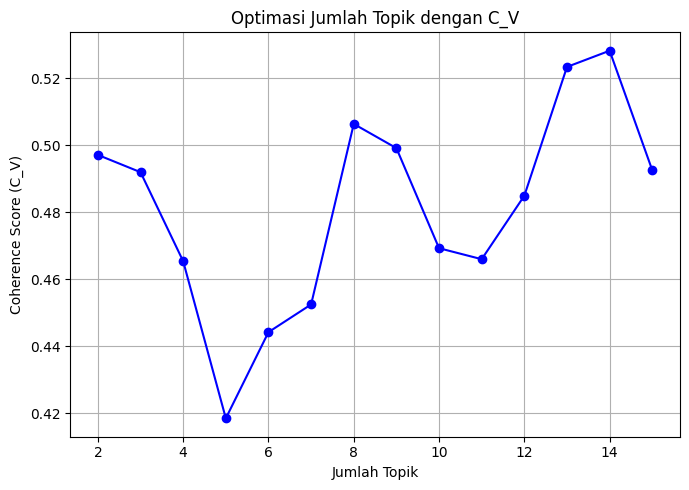

Topik 2: c_v=0.4971
Topik 3: c_v=0.4920
Topik 4: c_v=0.4653
Topik 5: c_v=0.4184
Topik 6: c_v=0.4442
Topik 7: c_v=0.4524
Topik 8: c_v=0.5064
Topik 9: c_v=0.4991
Topik 10: c_v=0.4692
Topik 11: c_v=0.4660
Topik 12: c_v=0.4849
Topik 13: c_v=0.5234
Topik 14: c_v=0.5282
Topik 15: c_v=0.4925

Jumlah topik optimal berdasarkan c_v tertinggi: 14


In [20]:
plt.figure(figsize=(7, 5))
plt.plot(topic_range, coherence_cv, marker='o', color='b')
plt.xlabel('Jumlah Topik')
plt.ylabel('Coherence Score (C_V)')
plt.title('Optimasi Jumlah Topik dengan C_V')
plt.grid(True)
plt.tight_layout()
plt.savefig('resultModel_LDA/coherence_optimization.png', dpi=150)
plt.show()

for t, cv in zip(topic_range, coherence_cv):
    print(f"Topik {t}: c_v={cv:.4f}")

optimal_topics = topic_range[np.argmax(coherence_cv)]
print(f"\nJumlah topik optimal berdasarkan c_v tertinggi: {optimal_topics}")

In [21]:
num_topics_final = optimal_topics
passes_final = 50

print(f"Melatih model final dengan {num_topics_final} topik, passes={passes_final}...")
lda_final = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics_final,
    random_state=42,
    passes=passes_final,
    alpha='auto',
    per_word_topics=True
)

coh_final = CoherenceModel(
    model=lda_final,
    texts=df['tokens'].tolist(),
    dictionary=id2word,
    coherence='c_v'
).get_coherence()
print(f"Coherence Score Final (c_v): {coh_final:.4f}")

Melatih model final dengan 14 topik, passes=50...
Coherence Score Final (c_v): 0.5433


In [22]:
print("Topik-topik yang ditemukan:")
for idx, topic in lda_final.print_topics(num_words=10):
    print(f"Topik {idx}: {topic}")

def get_topic_keywords(lda_model, topic_id, num_words=5):
    words = lda_model.show_topic(topic_id, topn=num_words)
    return [word for word, prob in words]

print()
print("=================================================================\n")

topic_labels = {}
for i in range(num_topics_final):
    keywords = get_topic_keywords(lda_final, i, 5)
    label = ' + '.join(keywords)
    topic_labels[i] = label
    print(f"Topik {i}: {label}")

Topik-topik yang ditemukan:
Topik 0: 0.044*"bbm" + 0.028*"campur" + 0.021*"posko" + 0.020*"kualitas" + 0.020*"ega" + 0.016*"adu" + 0.016*"warna" + 0.012*"mobility" + 0.011*"pertalite" + 0.010*"pasuruan"
Topik 1: 0.034*"energi" + 0.022*"bahan" + 0.021*"indonesia" + 0.019*"perintah" + 0.017*"campur" + 0.017*"terap" + 0.017*"persen" + 0.016*"sumber" + 0.016*"bahlil" + 0.015*"daya"
Topik 2: 0.010*"hasil" + 0.009*"teman" + 0.009*"ojol" + 0.009*"sih" + 0.009*"mati" + 0.009*"perhati" + 0.009*"bukti" + 0.009*"temu" + 0.008*"periksa" + 0.008*"polres"
Topik 3: 0.053*"daerah" + 0.043*"papua" + 0.041*"bbm" + 0.031*"hilang" + 0.030*"triliun" + 0.025*"tenaga" + 0.024*"hasil" + 0.024*"prabowo" + 0.023*"sawit" + 0.022*"tanam"
Topik 4: 0.050*"mesin" + 0.047*"bakar" + 0.037*"bahan" + 0.030*"bensin" + 0.029*"campur" + 0.018*"kendara" + 0.013*"air" + 0.013*"persen" + 0.012*"ron" + 0.012*"emisi"
Topik 5: 0.037*"tanam" + 0.030*"pertamax" + 0.026*"green" + 0.024*"milik" + 0.023*"bahan" + 0.018*"jawa" + 0.017

In [23]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_final, corpus, id2word)
pyLDAvis.save_html(vis, 'resultModel_LDA/lda_visualization.html')
print("Visualisasi disimpan sebagai 'lda_visualization.html'")

Visualisasi disimpan sebagai 'lda_visualization.html'


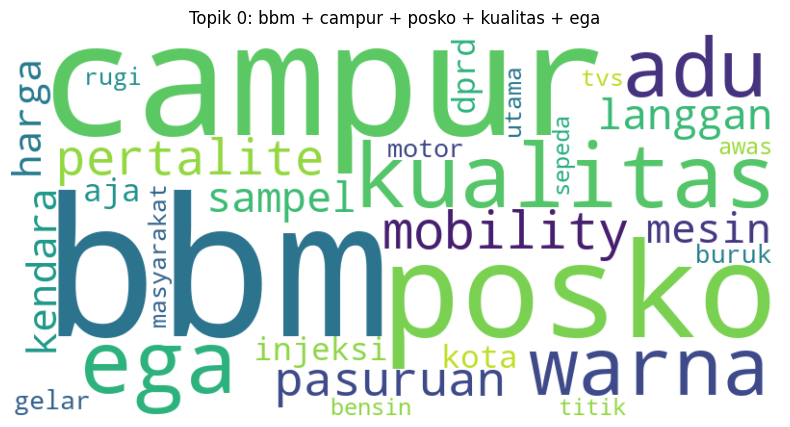

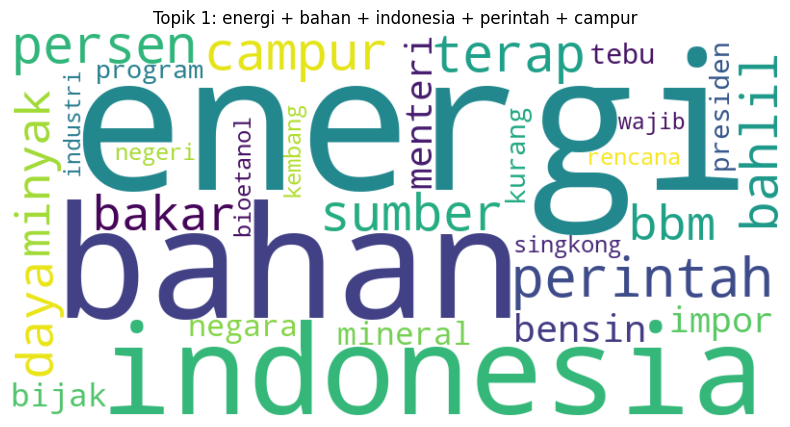

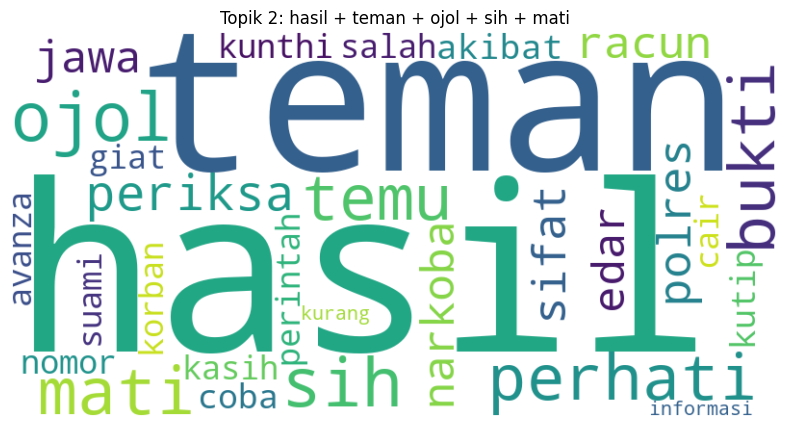

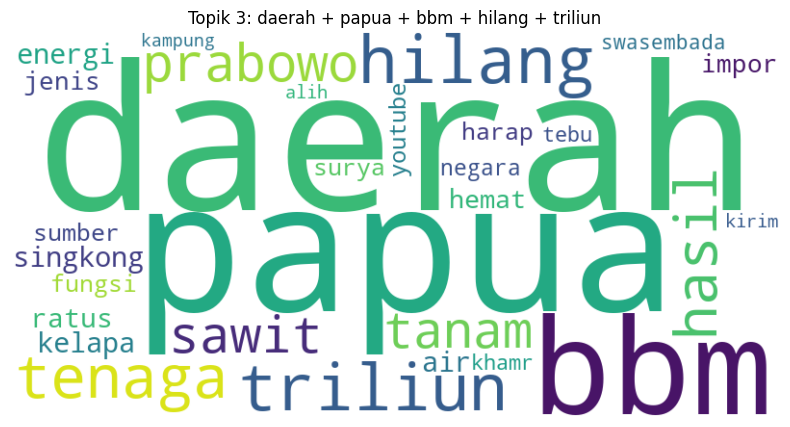

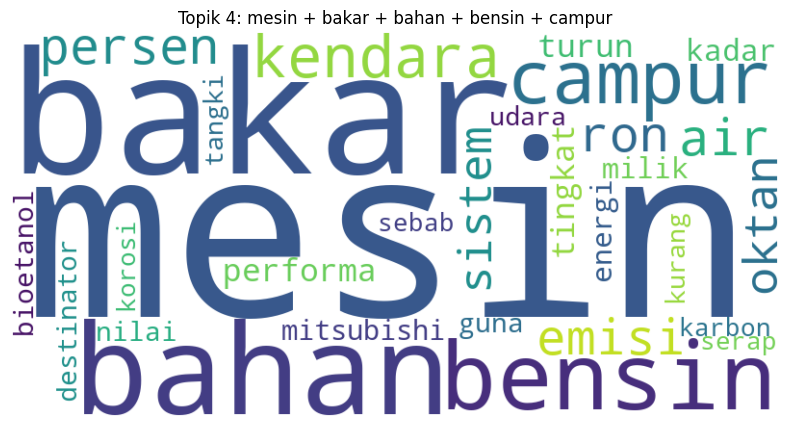

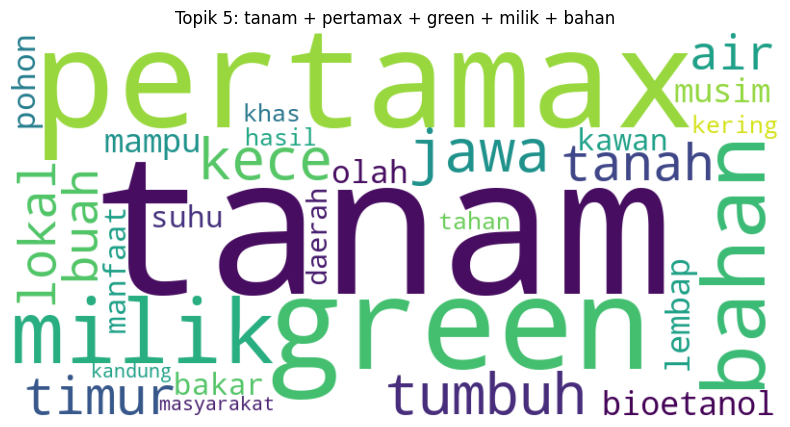

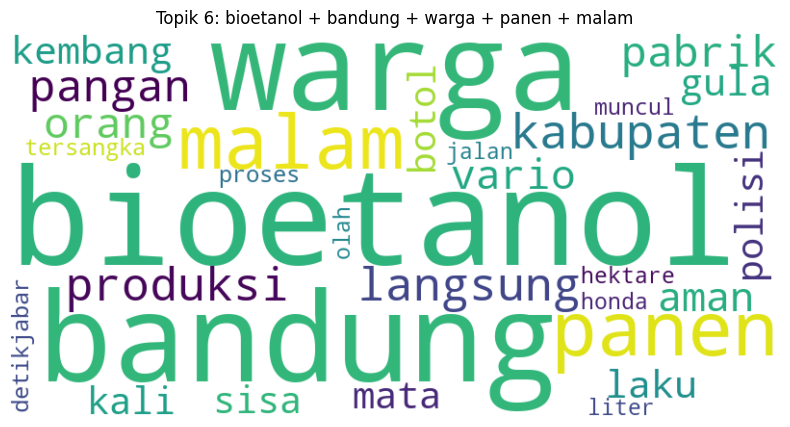

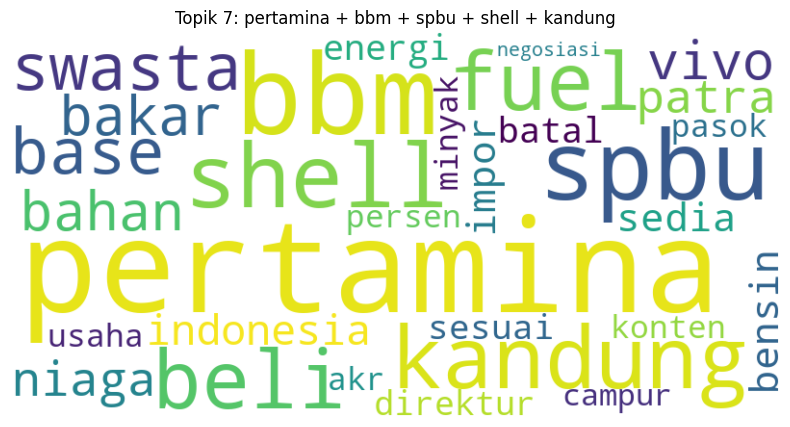

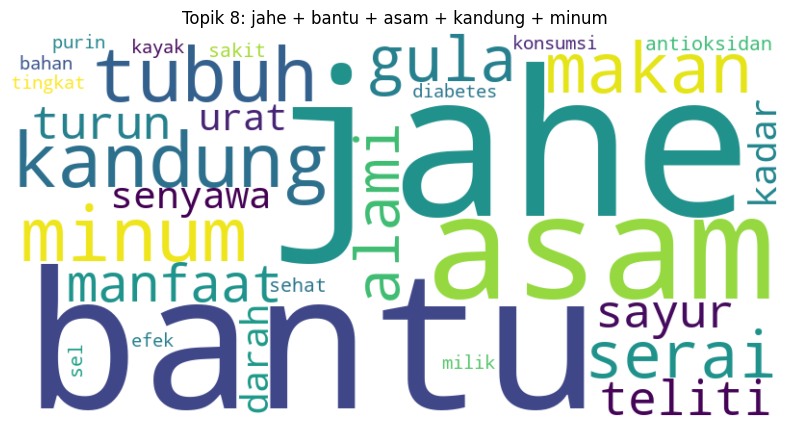

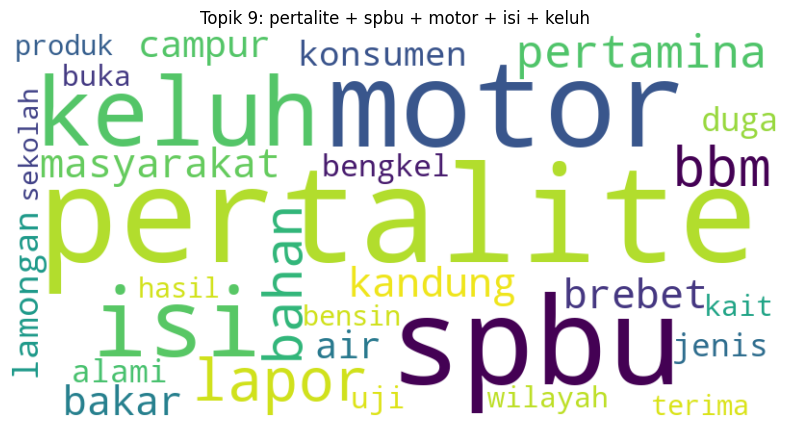

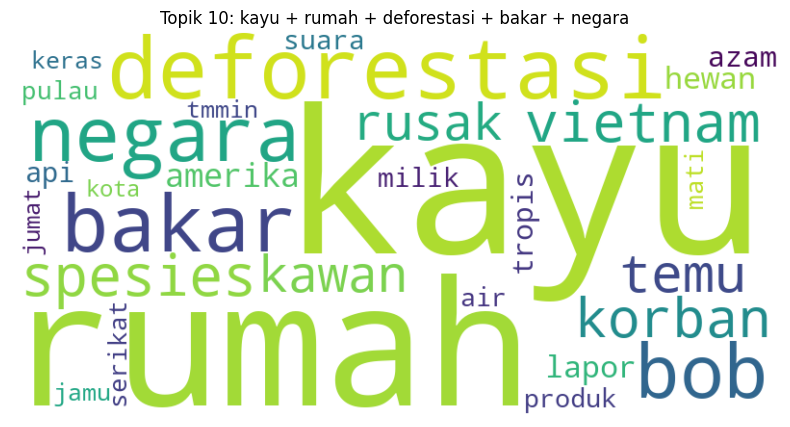

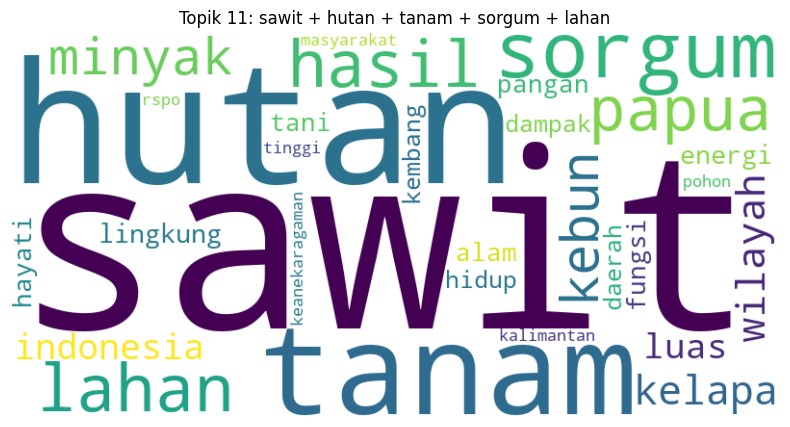

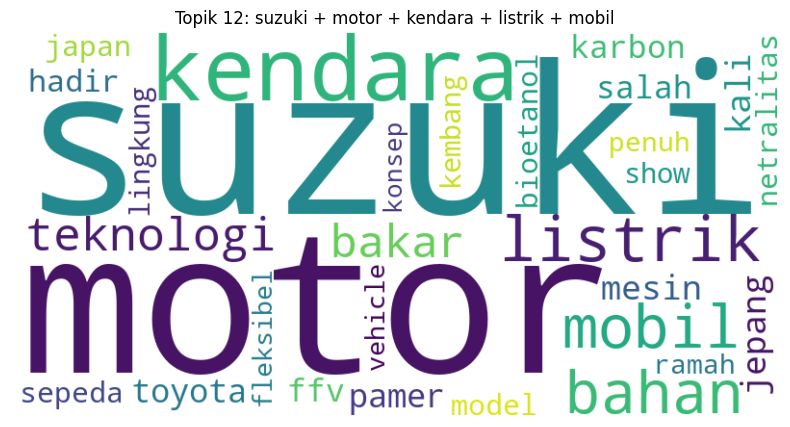

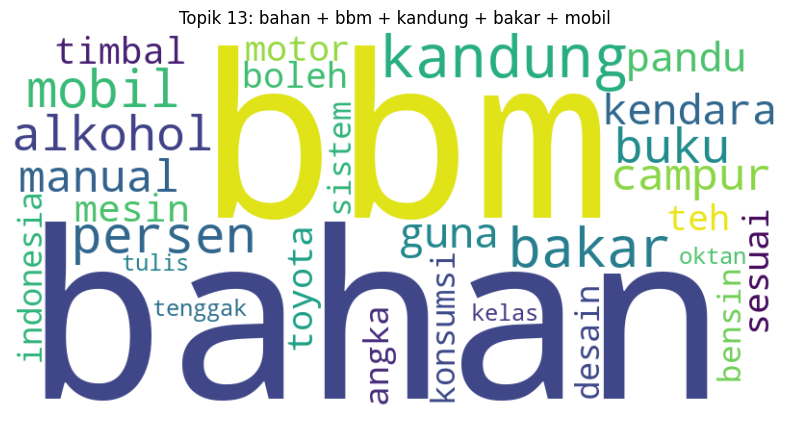

In [24]:
def plot_wordcloud_topic(lda_model, topic_id, dictionary, num_words=30):
    words = lda_model.show_topic(topic_id, topn=num_words)
    word_freq = {word: prob for word, prob in words}
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='viridis', max_words=num_words)
    wc.generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topik {topic_id}: {topic_labels[topic_id]}')
    plt.savefig(f'resultModel_LDA/word_cloud/wordcloud_topic_{topic_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

for i in range(num_topics_final):
    plot_wordcloud_topic(lda_final, i, id2word, num_words=30)

   id  dominant_topic  topic_prob
0   1              13    0.348327
1   2              12    0.577741
2   3               4    0.374119
3   4               4    0.412661
4   5               0    0.322982
5   6               4    0.506077
6   7              13    0.322163
7   8               8    0.342055
8   9               1    0.453818
9  10               1    0.464086


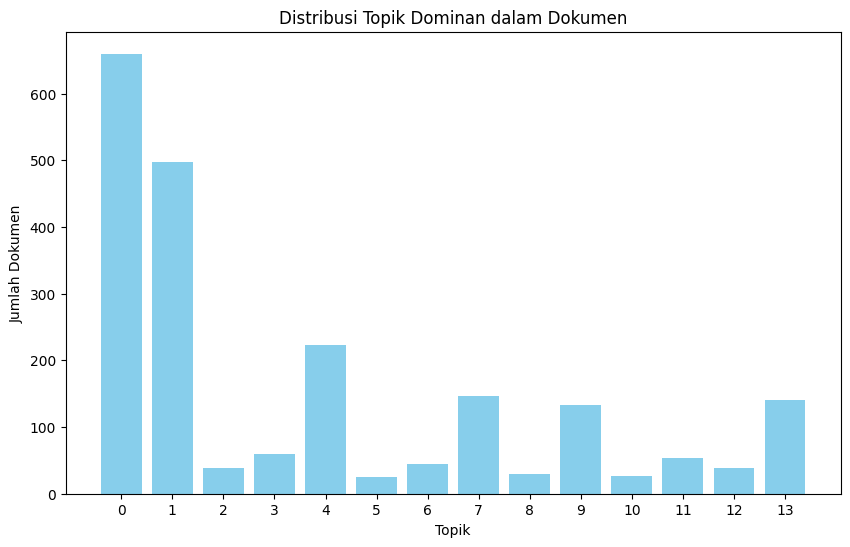

In [25]:
def get_dominant_topic(lda_model, corpus):
    dominant_topics = []
    topic_probs = []
    for doc_bow in corpus:
        doc_topics = lda_model.get_document_topics(doc_bow)
        dominant = max(doc_topics, key=lambda x: x[1])
        dominant_topics.append(dominant[0])
        topic_probs.append(dominant[1])
    return dominant_topics, topic_probs

dominant_topics, topic_probs = get_dominant_topic(lda_final, corpus)

df['dominant_topic'] = dominant_topics
df['topic_prob'] = topic_probs

print(df[['id', 'dominant_topic', 'topic_prob']].head(10))

df.to_csv('resultModel_LDA/documents_with_topics.csv', index=False)

plt.figure(figsize=(10, 6))
topic_counts = df['dominant_topic'].value_counts().sort_index()
plt.bar(topic_counts.index, topic_counts.values, color='skyblue')
plt.xlabel('Topik')
plt.ylabel('Jumlah Dokumen')
plt.title('Distribusi Topik Dominan dalam Dokumen')
plt.xticks(range(num_topics_final))
plt.savefig('resultModel_LDA/topic_distribution.png', dpi=150)
plt.show()

In [26]:
lda_final.save('resultModel_LDA/lda_model_final.model')
id2word.save('resultModel_LDA/dictionary.dict')

with open('resultModel_LDA/corpus.pkl', 'wb') as f:
    pickle.dump(corpus, f)

with open('resultModel_LDA/topic_labels.pkl', 'wb') as f:
    pickle.dump(topic_labels, f)

print("Model, dictionary, corpus, dan topic labels berhasil disimpan.")

Model, dictionary, corpus, dan topic labels berhasil disimpan.
